<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import anndata as ad
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))

# Intro

We'll walk through how to run CellSweep on a scRNA-seq dataset. For this example, we'll be using the following dataset:

PBMC 1K from healthy donor (10x Genomics): https://www.10xgenomics.com/datasets/human-pbmc-from-a-healthy-donor-1-k-cells-v-2-2-standard-4-0-0

## Set up paths and parameters

In [3]:
expected_cells = 1000

data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "pbmc1k")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "pbmc1k")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

## Download data

In [4]:
adata_raw_path = os.path.join(data_dir, "sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5")
if not os.path.exists(adata_raw_path):
    !curl -L -o "{adata_raw_path}" "https://cf.10xgenomics.com/samples/cell-vdj/4.0.0/sc5p_v2_hs_PBMC_1k/sc5p_v2_hs_PBMC_1k_raw_feature_bc_matrix.h5"

## Load in data

In [5]:
adata_raw = sc.read_10x_h5(adata_raw_path)
adata_raw.var_names_make_unique()

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Identifying empty droplets (noncellular barcodes)

For high-throughput technologies (e.g., droplet-based or combinatorial barcoding methods), CellSweep relies on prior identification of **noncellular barcodes** (also called “empty droplets”) to estimate the ambient RNA distribution.

CellSweep expects a boolean column `adata.obs["is_empty"]`, where `True` indicates a barcode that does not originate from a cell and `False` indicates a barcode corresponding to a cell.

We recommend using a standard approach such as a knee plot or existing tools (e.g., EmptyDrops) to define this set. In this notebook, we use a fixed threshold based on the knee plot.

In practice, the exact choice of empty droplet detection method has only a modest effect on results. However, it is generally better to be conservative. Including true cells as “empty” can distort the estimated ambient profile, but missing some empty droplets is usually less harmful, as highly contaminated barcodes are often identified by the model (e.g., via high `alpha_hat`)

If no empty droplets are provided, CellSweep can attempt to estimate them automatically. However, this functionality is currently experimental and not recommended for routine use.

---

### Note: datasets without empty droplets

For low-throughput technologies (e.g., Smart-seq2), where cells are physically isolated, there may be few or no empty droplets. Similarly, some datasets may have already filtered out low-quality barcodes.

In these cases, CellSweep can instead **estimate the ambient profile during training** rather than relying on predefined empty droplets. While this allows the method to run, it is empirically less stable than using explicitly identified empty barcodes.

This alternative mode is automatically activated if fewer than 10,000 empty droplets are provided. To enable it manually, set:

```
freeze_ambient_profile=False
```

We recommend using this mode only when noncellular barcodes are unavailable.


UMI cutoff for expected cells (1000): 257.00


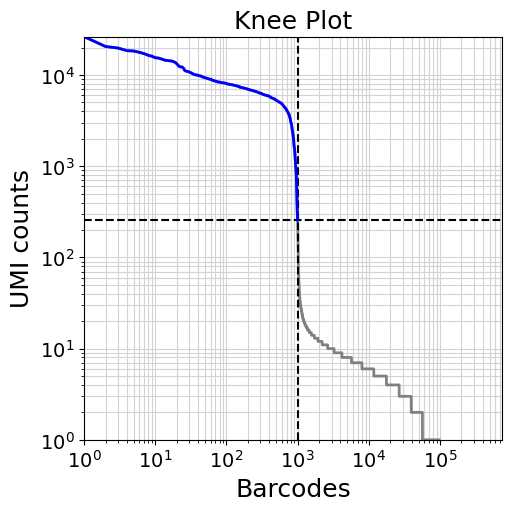

In [6]:
umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))
adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff)

## Perform QC and assign cell types

CellSweep requires a **discrete cell-type assignment** for each cell, which is used to estimate the expected biological signal, in column `adata.obs["celltype"]`(categorical). 

In practice, CellSweep is **robust to the choice of clustering or annotation method**, and we have observed similar results across various of approaches. For this tutorial, we use Leiden clustering to assign cell types.

Before clustering, we perform standard quality control (QC) to remove low-quality cells, as these can distort clustering results. While this step is not strictly required for CellSweep itself, it generally improves downstream annotations and overall performance.

Importantly, the CellSweep model **does not explicitly account for doublets**. As a result, we strongly recommend removing doublets prior to running CellSweep, as they can confound both clustering and contamination estimates.

In [7]:
min_genes = 10
max_mt_percent = 25
remove_doublets = True

In [8]:
# model_pkl = "Immune_All_High.pkl"  # for cell type assignment with celltypist
# adata_celltype = cs_utils.determine_cell_types(adata_raw, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=2)

adata_celltype = adata_raw[~adata_raw.obs["is_empty"]].copy()

if min_genes is not None:
    sc.pp.filter_cells(adata_celltype, min_genes=min_genes)

sc.pp.filter_genes(adata_celltype, min_cells=1)

if max_mt_percent is not None:
    adata_celltype.var["mt"] = adata_celltype.var_names.str.upper().str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata_celltype, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
    adata_celltype = adata_celltype[adata_celltype.obs.pct_counts_mt < max_mt_percent, :]

if remove_doublets:
    sc.pp.scrublet(adata_celltype)
    adata_celltype = adata_celltype[~adata_celltype.obs["predicted_doublet"]]

adata_celltype.layers["counts"] = adata_celltype.X.copy()
sc.pp.normalize_total(adata_celltype, target_sum=1e4)
sc.pp.log1p(adata_celltype)
sc.pp.highly_variable_genes(adata_celltype, n_top_genes=2000)
sc.tl.pca(adata_celltype, svd_solver="arpack", random_state=42)
sc.pp.neighbors(adata_celltype, n_neighbors=15, n_pcs=50)
sc.tl.leiden(adata_celltype, flavor="igraph", n_iterations=2, resolution=1.0, random_state=42)

adata_raw.obs["celltype"] = adata_celltype.obs["leiden"].cat.add_categories(["empty"]).reindex(adata_raw.obs.index).fillna("empty")

adata_raw_cells_filtered = adata_raw[(adata_raw.obs["is_empty"] | adata_raw.obs_names.isin(adata_celltype.obs_names))].copy()  # keep empty droplets and cells that passed QC (min_genes, MT%, not doublets)
adata_raw_cells_filtered

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/scanpy/preprocessing/_scrublet/__init__.py:295: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["doublet_score"] = scrubbed["obs"]["doublet_score"]
/home/jrich/tmp/ipykernel_3886750/3126375534.py:20: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_celltype.layers["counts"] = adata_celltype.X.copy()


AnnData object with n_obs × n_vars = 737234 × 36601
    obs: 'is_empty', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

## Run cellsweep
Requires columns adata.obs["is_empty"] and adata.obs["celltype"] to be present.

In [9]:
adata_cellsweep_path = os.path.join(data_dir, "adata_cellsweep.h5ad")
log_file = os.path.join(data_dir, "cellsweep.log")

adata_cellsweep = denoise_count_matrix(adata_raw_cells_filtered, adata_out=adata_cellsweep_path, log_file=log_file, threads=2)
# adata_cellsweep = ad.read_h5ad(adata_cellsweep_path)

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc1k/cellsweep.log


In [10]:
adata_cellsweep

AnnData object with n_obs × n_vars = 737234 × 36601
    obs: 'is_empty', 'celltype', 'init_alpha', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient_profile', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'init_beta_hat', 'loglike'
    layers: 'raw'

## Filter empty droplets

In [11]:
adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep

AnnData object with n_obs × n_vars = 954 × 36601
    obs: 'is_empty', 'celltype', 'init_alpha', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient_profile', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'init_beta_hat', 'loglike'
    layers: 'raw'

## Plot a histogram of alpha_hat (predicted ambient fraction for each cell)

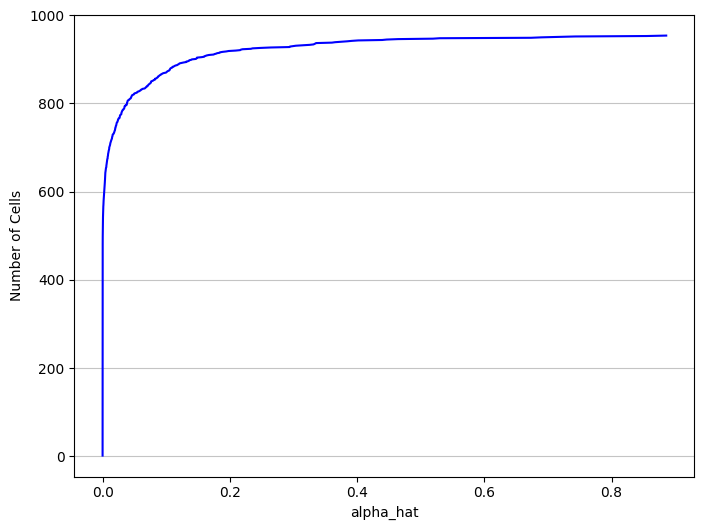

In [12]:
cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(out_dir, "alpha_hat_histogram.png"), kind="cdf")

## Let's use a threshold to remove noisy cells from our Anndata object

In [13]:
alpha_hat_threshold = 0.3
adata_cellsweep = adata_cellsweep[adata_cellsweep.obs["alpha_hat"] <= alpha_hat_threshold].copy()
adata_cellsweep

AnnData object with n_obs × n_vars = 930 × 36601
    obs: 'is_empty', 'celltype', 'init_alpha', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'ambient_profile', 'ambient_hat'
    uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'init_beta_hat', 'loglike'
    layers: 'raw'

## Let's make some scatterplots to visualize how much CellSweep modified our counts

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


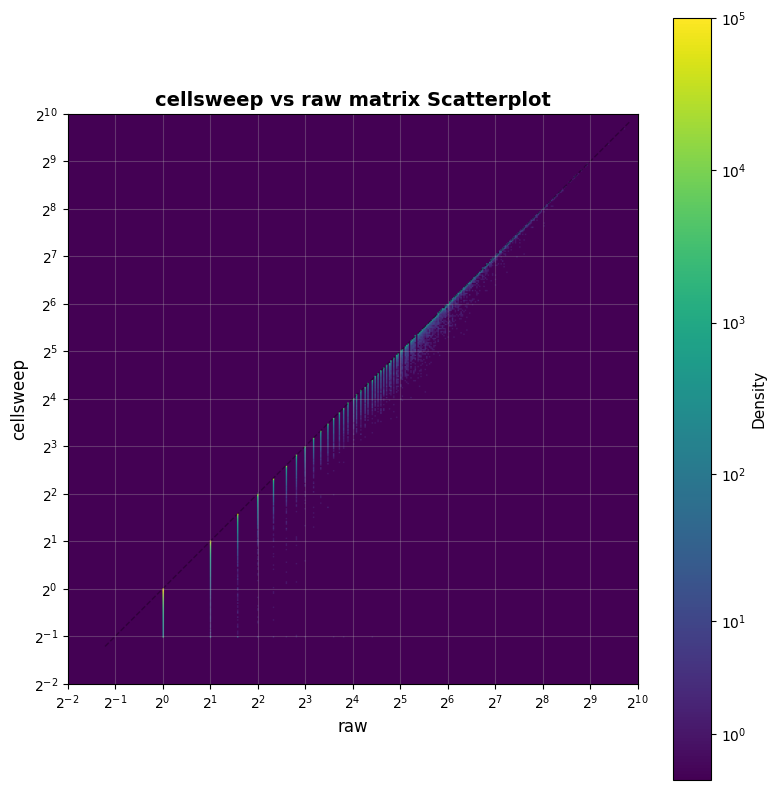

Creating scatterplot...
Calculating scatterplot...


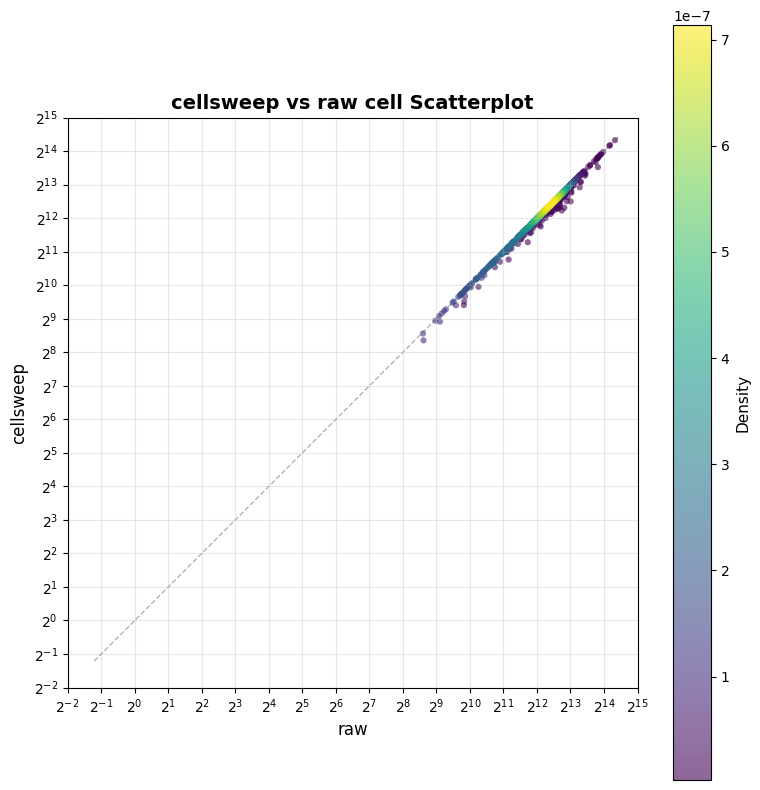

Creating scatterplot...
Calculating scatterplot...


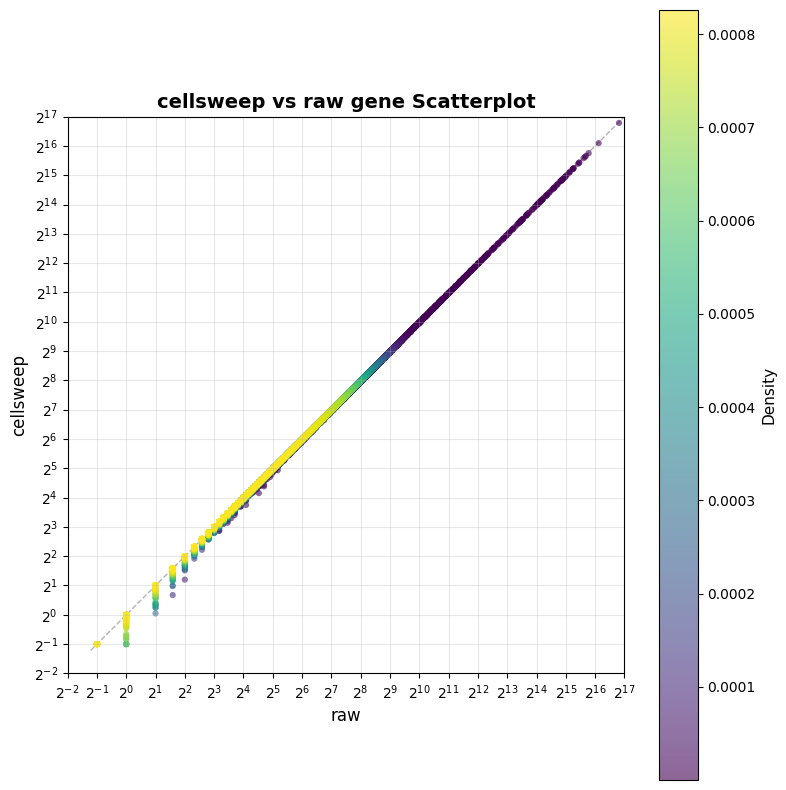

In [14]:
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cellsweep_vs_raw_matrix_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cellsweep_vs_raw_cell_expression_scatterplot.png"), show=True)
cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", out_path=os.path.join(out_dir, f"cellsweep_vs_raw_gene_expression_scatterplot.png"), show=True)

## Let's see which genes contributed most to the ambient signal

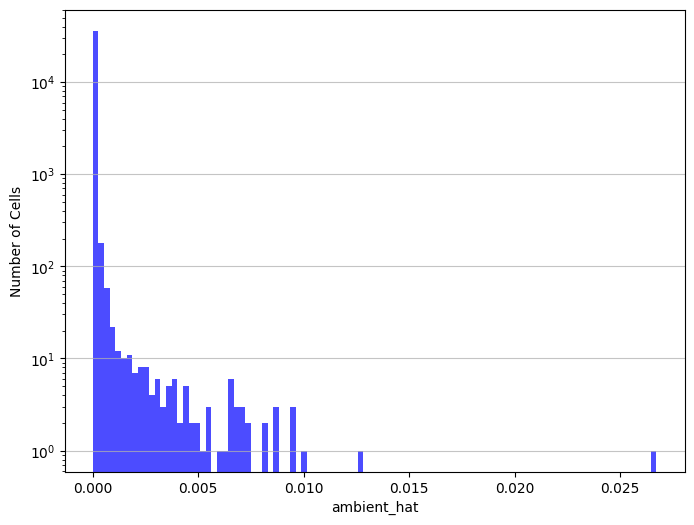

MALAT1: 0.02672107145190239
EEF1A1: 0.012765683233737946
RPLP1: 0.009988472796976566
RPS27: 0.009550542570650578
RPL41: 0.009543243795633316
RPS12: 0.00936807133257389
B2M: 0.008798761293292046
TMSB4X: 0.008776864968240261
RPL13: 0.008674681186676025
RPL10: 0.008273244835436344
MT-CO1: 0.008203905075788498
RPL32: 0.0072587053291499615
ACTB: 0.007233159150928259
RPL39: 0.007145572919398546
MT-CO2: 0.007032440975308418
RPL34: 0.007025142200291157
RPS27A: 0.006820774637162685
RPS15A: 0.00678063090890646
RPL30: 0.0067514353431761265
RPS28: 0.006601809058338404


In [15]:
cs_utils.plot_histogram(adata_cellsweep, adata_df="var", col="ambient_hat", out_path=os.path.join(out_dir, "ambient_hat_histogram.png"), kind="pdf", ylog=True)
cs_utils.print_top_ambient_genes(adata_cellsweep, top_n=20)

## If you want to work with the noise matrix, simply subtract cellsweep from raw

In [16]:
adata_cellsweep.layers["noise"] = adata_cellsweep.layers["raw"] - adata_cellsweep.X

## If you prefer the raw matrix over the CellSweep-corrected matrix, you can access the raw matrix in adata.layers["raw"]

In [17]:
adata_cellsweep.X = adata_cellsweep.layers["raw"]

## That's it! Happy sweeping!